In [1]:
# Importing packages and defining functions to read in the data
import glob
import pandas as pd
import numpy as np
import plotnine as p9


def make_date(x):
    """
    Makes a datetime object out of the Date and Time columns
    """
    return pd.to_datetime(x['Date'] + " " + x['Time'], format="%Y/%m/%d %I:%M %p")

def compute_precip(x):
    """
    Returns for each entry the amount of precipitation that has accumulated
    in the previous five minutes, inserting NA for any entry for which either:
        - the difference in accumulated precipitation is negative, or
        - the previous entry was not five minutes ago.
    """
    dt = x["Date"].diff().dt.seconds
    dp = np.maximum(0, x['Precip_Accum_mm'].diff()).mask(dt != 300, pd.NA)
    return dp

def read_weather_files(ddir):
    """
    Reads in all CSV files in the directory `ddir`, and returns a concatenated
    data frame. For each file, assumes that file names are of the form
    "something_CODE.csv"; and inserts "CODE into the "code" column of the result
    for that file.
    """
    wfiles = glob.glob(ddir + "/" + "*.csv")
    assert len(wfiles) > 0, "No files found."
    xl = []
    for f in wfiles:
        x = pd.read_csv(f).convert_dtypes()
        x['Date'] = make_date(x)
        x['code'] = f.split("/")[-1].split("_")[0] ## change "/" to "\\" on windows
        x['Precip_Amount_mm'] = compute_precip(x)
        xl.append(x)
    
    return pd.concat(xl)

In [2]:
# Reading in the weather data
weather = read_weather_files("data/weather_data")

,Date,Time,Temperature_C,Dew_Point_C,Humidity_%,Wind,Speed_kmh,Gust_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,UV,Solar_w/m2,code,Precip_Amount_mm
0,2024-01-01 00:04:00,12:04 AM,4.11,3.67,97,ENE,0.0,0.0,1022.69,0.0,0.25,0,0.0,KOREUGEN31,<NA>
1,2024-01-01 00:09:00,12:09 AM,4.17,3.72,97,ENE,0.0,0.0,1022.69,0.0,0.0,0,0.0,KOREUGEN31,0.0
2,2024-01-01 00:14:00,12:14 AM,4.17,3.72,97,ENE,0.0,0.0,1022.69,0.0,0.0,0,0.0,KOREUGEN31,0.0
3,2024-01-01 00:19:00,12:19 AM,4.17,3.72,97,ENE,0.0,0.0,1022.69,0.0,0.0,0,0.0,KOREUGEN31,0.0
4,2024-01-01 00:24:00,12:24 AM,4.17,3.72,97,ENE,0.0,0.0,1023.03,0.0,0.0,0,0.0,KOREUGEN31,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75202,2025-12-31 23:39:00,11:39 PM,2.28,2.0,98,NNW,0.0,0.0,993.57,0.0,0.0,0,0.0,KOREUGEN319,0.0
75203,2025-12-31 23:44:00,11:44 PM,2.28,2.0,98,NW,0.0,0.0,993.23,0.0,0.0,0,0.0,KOREUGEN319,0.0
75204,2025-12-31 23:49:00,11:49 PM,2.28,2.0,98,NW,0.0,0.0,993.23,0.0,0.0,0,0.0,KOREUGEN319,0.0
75205,2025-12-31 23:54:00,11:54 PM,2.33,2.06,98,NW,0.0,0.0,993.23,0.0,0.0,0,0.0,KOREUGEN319,0.0


In [3]:
# Reading in the stations data
stations = pd.read_csv("data/stations.csv")

,name,code,lat,lon,elev
0,BETHEL,KOREUGEN31,44.080,123.200,380
1,Torrington Station,KOREUGEN67,44.120,123.150,377
2,South Eugene,KOREUGEN74,44.030,123.110,440
3,South University,KOREUGEN127,44.037,123.074,470
4,Old Baldy,KOREUGEN225,44.000,123.070,800
5,Lafferty Park,KOREUGEN226,44.020,123.100,640
6,Crescent Ave,KOREUGEN249,44.090,123.080,410
7,Alvadore,KOREUGEN260,44.100,123.270,400
8,Lema,KOREUGEN295,44.080,123.130,410
9,College Hill,KOREUGEN303,44.030,123.100,587


# Homework 03

Natalie Vogel  
2026-01-26

# Introduction

Here in Eugene, our official weather data comes from a station located at the Eugene Airport. This station is a little over 10 miles away from the University of Orgeon and nearby neighborhoods, so some people have installed personal weather stations on their houses or in their neighborhoods to get more localized weather data. In this report, we will be analyzing local weather station data in Eugene to explore how well measurements from one station predict measurements at other stations, and region-wide averages. The local weather data we will be using was originally accessed from [Weather Underground](https://www.wunderground.com/about/data), and was provided to us by our Professor, Peter Ralph. 

### Let's take a tour of the local weather data

There are 39 personal weather stations in Eugene. In the figure below, you can see where these are located, and where they are in reference to the main weather station at the Eugene Airport and the University of Oregon. 

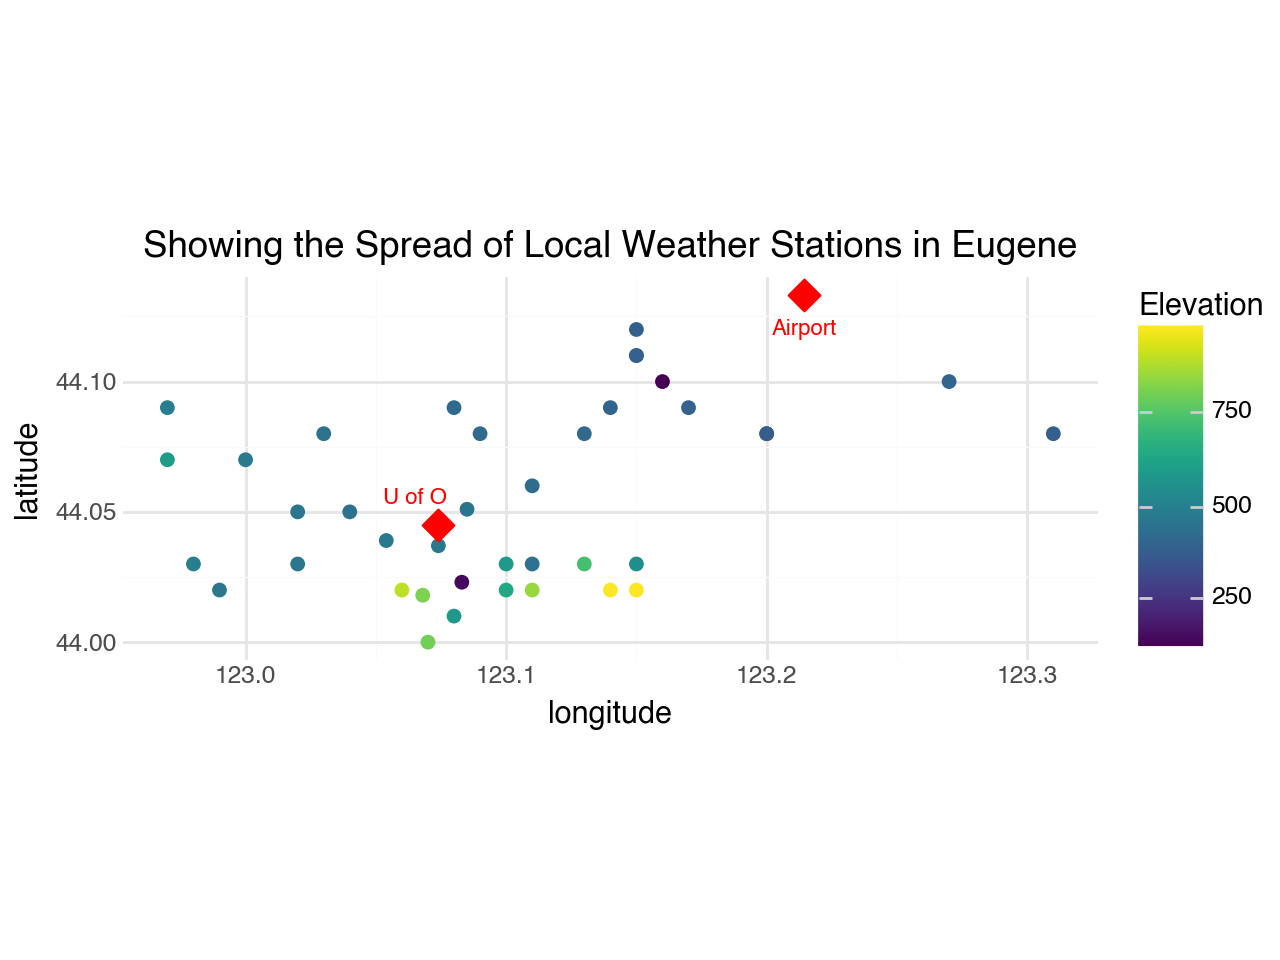

In [4]:
(
    p9.ggplot(data = stations,
              mapping = p9.aes(x = "lon", y = "lat", color = "elev")) +
    p9.geom_point(size = 2) +
    p9.coord_fixed() +
    p9.theme_minimal() +
    p9.labs(title = "Showing the Spread of Local Weather Stations in Eugene",
           x = "longitude",
           y = "latitude",
           color = "Elevation") +
    # adding in the airport and U of O (EMU) for reference, lat/lon coordinates via weather.gov and Google Maps:
    p9.annotate("point", x = 123.21444, y = 44.13333, shape = "D", color = "red", size = 4) + 
    p9.annotate("text", x = 123.21444, y = 44.12, label = "Airport", color = "red", size = 8) +
    p9.annotate("point", x = 123.0737, y = 44.0449, shape = "D", color = "red", size = 4) + 
    p9.annotate("text", x = 123.065, y = 44.055, label = "U of O", color = "red", size = 8)
)

The dataset we will be using is a snapshot of 14 of these weather stations from the years 2015, 2024, and 2025. However, not every station we'll be looking at has data from all three of these years because different people may have gotten or gotten rid of their personal weather stations at different times. **Let me show you what I mean** - here is a table showing the number of observations (data points) from each station in each year:

In [5]:
pd.crosstab(weather['code'], weather['Date'].dt.year)

Date,2015,2024,2025
code,,,
KOREUGEN127,0,0,98541
KOREUGEN249,0,0,97346
KOREUGEN267,0,0,77024
KOREUGEN295,0,0,97577
KOREUGEN303,0,0,97480
KOREUGEN307,0,0,98181
KOREUGEN31,102093,102832,0
KOREUGEN319,0,0,75207
KOREUGEN321,0,0,92791


But this doesn't mean we don't have enough data... When in use, each of these stations collects data **every five minutes** about temperature, dew point, humidity, wind direction/speed/gusts, barometric pressure, precipitation rate/amount, UV index, and solar irradiance. That's a *lot* of data, around 1.3 million observations to be specific. 

In this report, I'm going to hone in on one piece of the data: **rainfall.** Accurate rainfall prediction is important. Not only does it suck when the weather app says no rain until 2pm and then it starts raining during your 10am bike ride to class, accurate rainfall prediction is also important for things like anticipating load for our city's stormwater system and electricity-producing dams. In what follows, I'll explain what I did to clean up the data, and explore questions like:

* How does typical rainfall vary though the year?

* Does it tend to rain more at certain hours of the day?

* How much does the total hourly rainfall in each location differ from the mean across all locations?

* How much does the total daily rainfall in each location differ from the mean across all locations?


# Cleaning

To clean up the data, I first went on a hunt for NA values:

In [24]:
weather.isna().sum()

Date                     0
Time                     0
Temperature_C        49136
Dew_Point_C          49259
Humidity_%           49136
Wind                 36935
Speed_kmh            48567
Gust_kmh             49289
Pressure_hPa            66
Precip_Rate_mm       49314
Precip_Accum_mm      48842
UV                  168563
Solar_w/m2               0
code                     0
Precip_Amount_mm     91578
dtype: int64

It looks like there are no missing dates/timestamps which is great, but there are missing values for `Precip_Amount_mm`, which is the rainfall variable we're looking at. I decided to drop the observations where this variable was missing:

In [34]:
weather.dropna(subset = ["Precip_Amount_mm"], inplace = True)

weather["Precip_Amount_mm"].isna().sum()

np.int64(0)

Now that the NAs are taken care of, let's make sure there aren't any negative or obviously wrong rainfall values.

A summary:

In [46]:
weather["Precip_Amount_mm"].describe()

count    1265578.0
mean      0.008973
std       0.068707
min            0.0
25%            0.0
50%            0.0
75%            0.0
max          13.46
Name: Precip_Amount_mm, dtype: Float64

Hmm, I'm curious about that maximum given that the upper quartile is 0. 

Let's look at the top ten largest values for rainfall:

In [55]:
weather["Precip_Amount_mm"].nlargest(10)

83281    13.46
48510     12.7
87397    11.43
18156    10.67
77116     9.65
65072     6.85
7474      6.35
430       6.35
61560     6.35
36702     5.34
Name: Precip_Amount_mm, dtype: Float64

Okay, looks fine to me! No obviously wrong rainfall values here. Let's make some graphs!

# Analysis

The first question we want to explore is **how does typical rainfall vary throughout the year?**

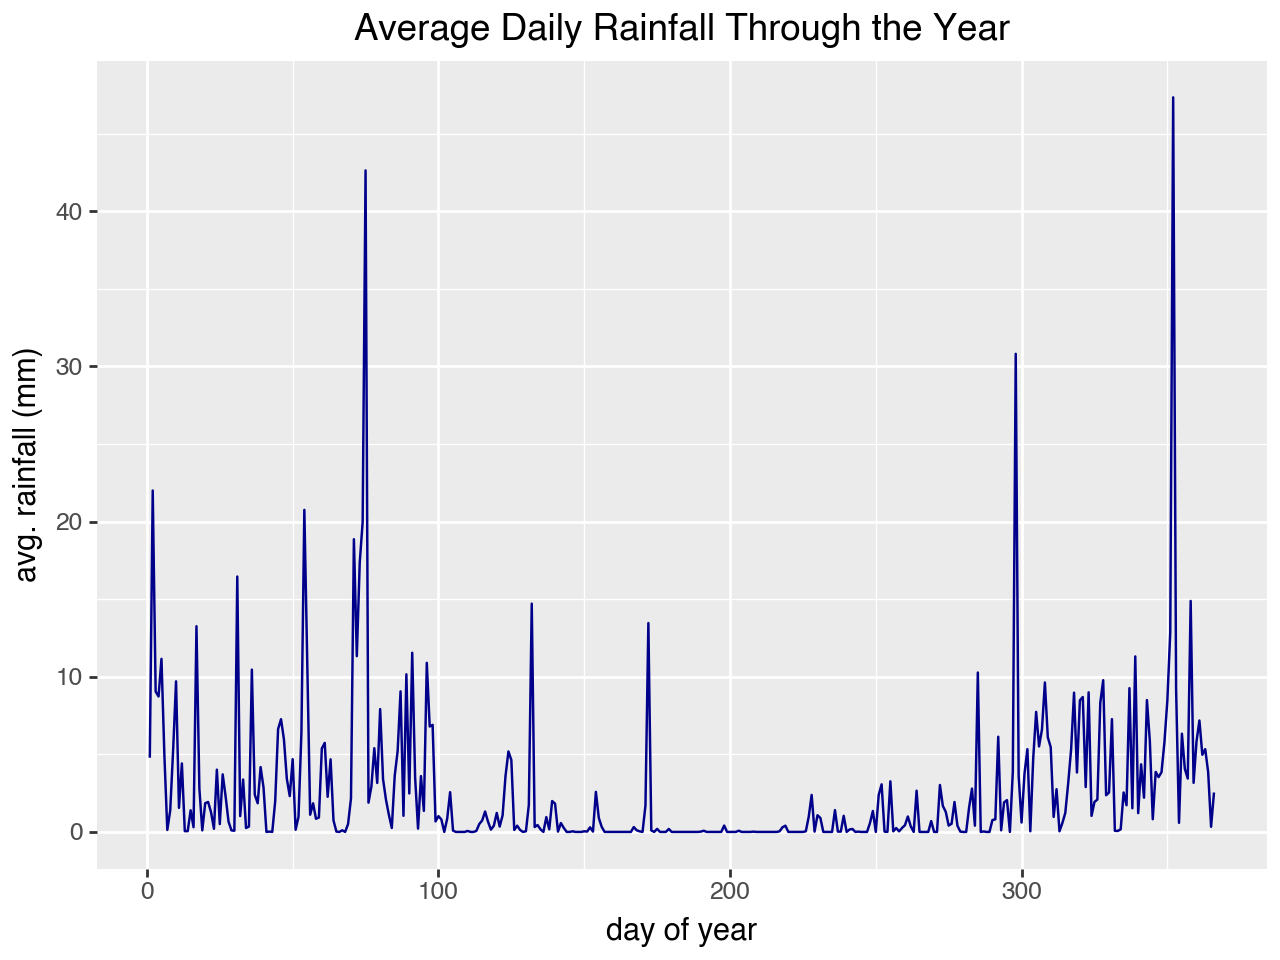

In [73]:
day_rain = (
    weather.assign(day = lambda df: df['Date'].dt.dayofyear)
    .groupby(["day", "code"])
    .aggregate(
        Precip_Amount_mm = ("Precip_Amount_mm", "sum"),
    ).reset_index()
    .groupby("day")
    .aggregate(
        Precip_Amount_mm = ("Precip_Amount_mm", "mean"),
    ).reset_index()
)

(
    p9.ggplot(data = day_rain, 
              mapping = p9.aes(x = "day", y = "Precip_Amount_mm")) + 
    p9.geom_line(color = "darkblue") +
    p9.labs(title = "Average Daily Rainfall Through the Year",
            y = "avg. rainfall (mm)",
            x = "day of year")
)

Here, average means "average of total daily rainfall across stations", so this graph shows us how much rainfall a typical local weather stations gets on each day of the year. 

Here we see relatively low average daily rainfall, with most days accumulating less than half an inch (~13mm). There is a clear dropoff in daily average rainfall from around day 165 to day 230, which correspond to the beginning of June and the middle/end of August - so, as to be expected for Summer. The peaks in daily average rainfall were around the end of March, the end of October, and the highest peak in the middle of December. I refer to the variable of interest as "rainfall", but it's really measuring precipitation, so I wonder if the peak in December could be (at least partially) due to snow!

<br>

The next question to explore is **does it tend to rain more at certain hours of the day?**

/Users/natalievogel/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/plotnine/positions/position_stack.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


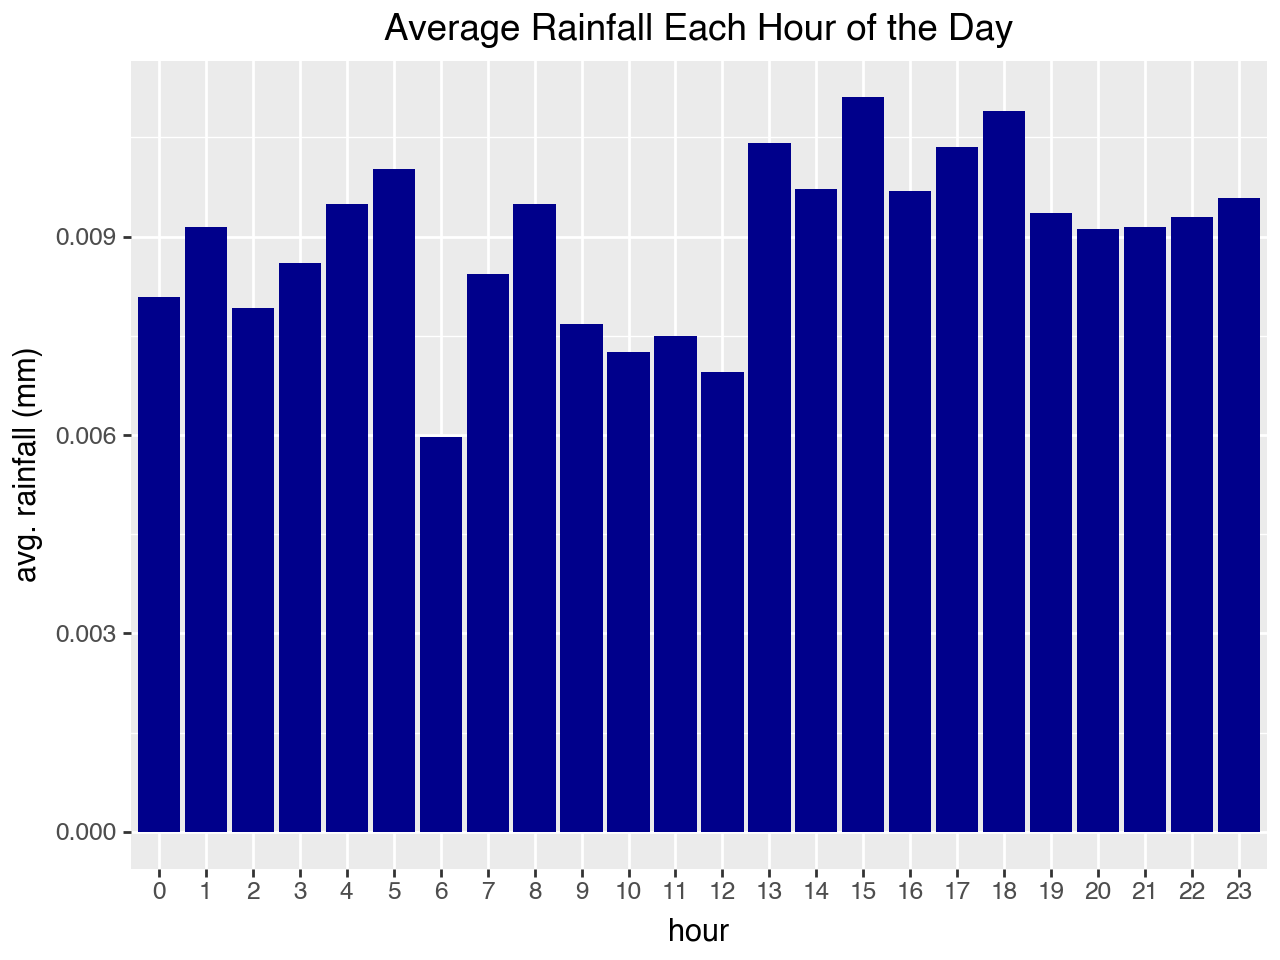

In [120]:
hourly_rain = (
    weather.assign(hour = lambda df: df['Date'].dt.hour)
    .groupby(["hour"])
    .aggregate(rainfall = ("Precip_Amount_mm", "mean"))
    .reset_index()
)

(
    p9.ggplot(data = hourly_rain, 
              mapping = p9.aes(x = "factor(hour)", y = "rainfall")) + 
    p9.geom_col(fill = "darkblue") +
    p9.labs(title = "Average Rainfall Each Hour of the Day",
            y = "avg. rainfall (mm)",
            x = "hour")
)

This graph shows us the average amount it rains each hour, where the average is calculated across all the 5-minute-increments each hour (regardless of which weather station they were taken by). It doesn't look like it tends to rain more at certain hours of the day in any significant way to me. 

Next question: **How much does the total *hourly* rainfall in each location differ from the mean across all locations?**

A raw look:

In [125]:
compare_rain_h = (
    weather.loc[:,['code', 'Date', 'Precip_Amount_mm']]
    .assign(Date = lambda df: df['Date'].dt.round('h'))
    .groupby(["code", 'Date'])
    .mean()
    .reset_index()
)

compare_rain_h['rain_relative'] = (
    compare_rain_h.loc[:,['Date','Precip_Amount_mm']]
    .groupby("Date")
    .transform(
        lambda x: x - x.mean()
    )
)

compare_rain_h

,code,Date,Precip_Amount_mm,rain_relative
0,KOREUGEN127,2025-01-01 00:00:00,0.05,0.029394
1,KOREUGEN127,2025-01-01 01:00:00,0.021667,-0.002111
2,KOREUGEN127,2025-01-01 02:00:00,0.020833,0.01466
3,KOREUGEN127,2025-01-01 03:00:00,0.0,0.0
4,KOREUGEN127,2025-01-01 04:00:00,0.0,-0.002083
...,...,...,...,...
109824,KOREUGEN74,2025-12-31 20:00:00,0.0,0.0
109825,KOREUGEN74,2025-12-31 21:00:00,0.0,0.0
109826,KOREUGEN74,2025-12-31 22:00:00,0.0,0.0
109827,KOREUGEN74,2025-12-31 23:00:00,0.0,0.0


A graphical look:

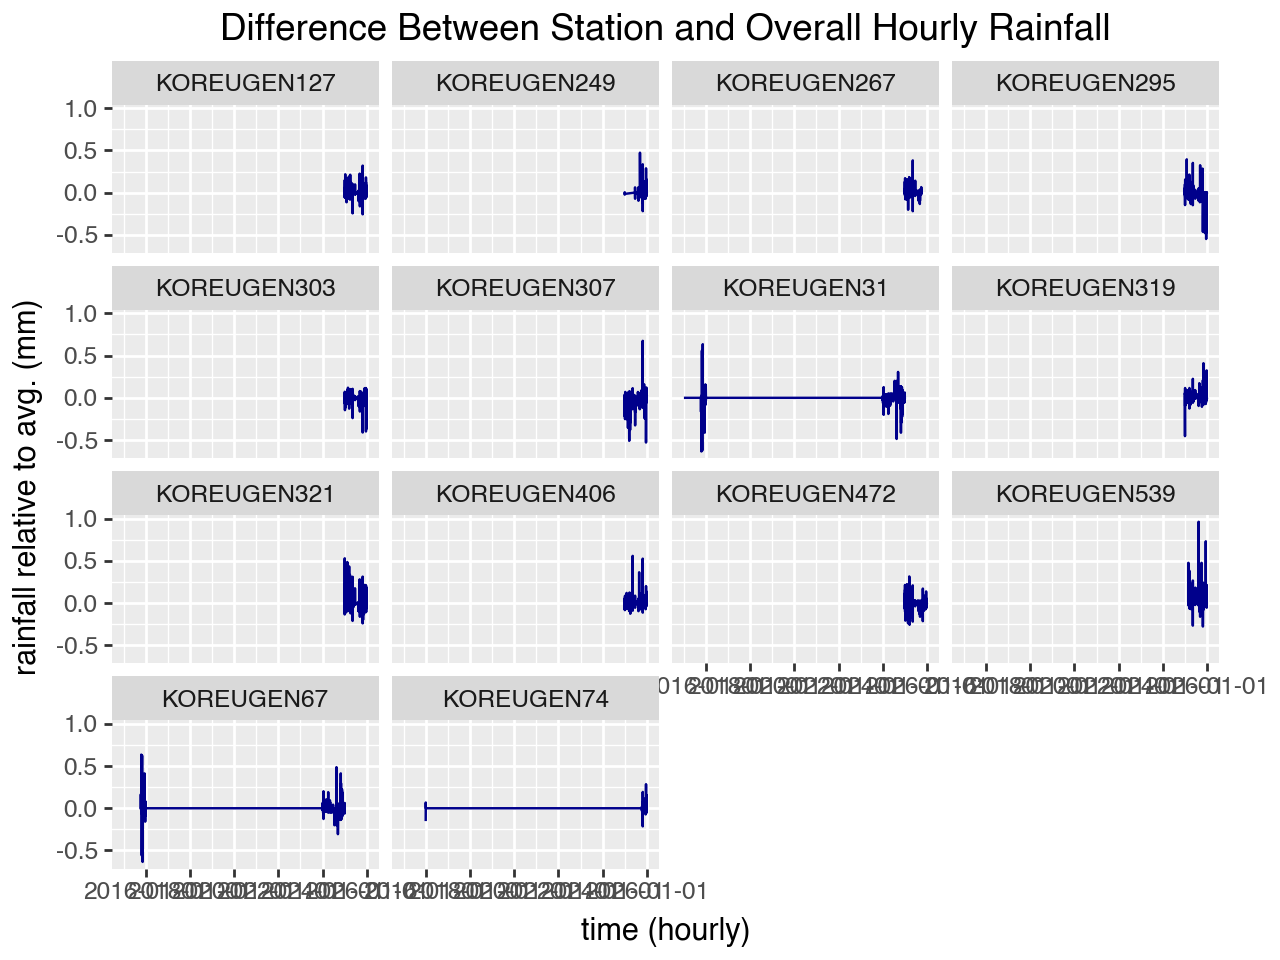

In [131]:
(
    p9.ggplot(data = compare_rain_h,
              mapping = p9.aes(x = "Date",
                               y = "rain_relative")) +
    p9.geom_line(color = "darkblue") +
    p9.facet_wrap("code") +
    p9.labs(title = "Difference Between Station and Overall Hourly Rainfall",
            x = "time (hourly)",
            y = "rainfall relative to avg. (mm)")

)

This graph shows, for each station, the difference between their hourly rainfall and the average rainfall across all stations for that hour, for every hour of every day available in the data. 

The difference between each station's hourly rainfall amount and the average hourly amount across all stations isn't very big (up to 1 mm more or a half a mm less than average). This suggests that the average reading for precipitation amount across all these local weather stations is pretty representative of precipitation readings in specific areas. 

And now for the last question: **How much does the total *daily* rainfall in each location differ from the mean across all locations?**

A raw look:

In [140]:
compare_rain_d = (
    weather.loc[:,['code', 'Date', 'Precip_Amount_mm']]
    .assign(Date = lambda df: df['Date'].dt.date)
    .groupby(["code", 'Date'])
    .mean()
    .reset_index()
)

compare_rain_d['rain_relative'] = (
    compare_rain_d.loc[:,['Date','Precip_Amount_mm']]
    .groupby("Date")
    .transform(
        lambda x: x - x.mean()
    )
)

compare_rain_d

,code,Date,Precip_Amount_mm,rain_relative
0,KOREUGEN127,2025-01-01,0.027422,0.003835
1,KOREUGEN127,2025-01-02,0.112014,0.008524
2,KOREUGEN127,2025-01-03,0.047639,0.000301
3,KOREUGEN127,2025-01-04,0.048507,0.007073
4,KOREUGEN127,2025-01-05,0.052917,-0.003295
...,...,...,...,...
4634,KOREUGEN74,2025-12-27,0.002639,0.00084
4635,KOREUGEN74,2025-12-28,0.000868,0.000781
4636,KOREUGEN74,2025-12-29,0.0,0.0
4637,KOREUGEN74,2025-12-30,0.0,-0.000166


A graphical look:

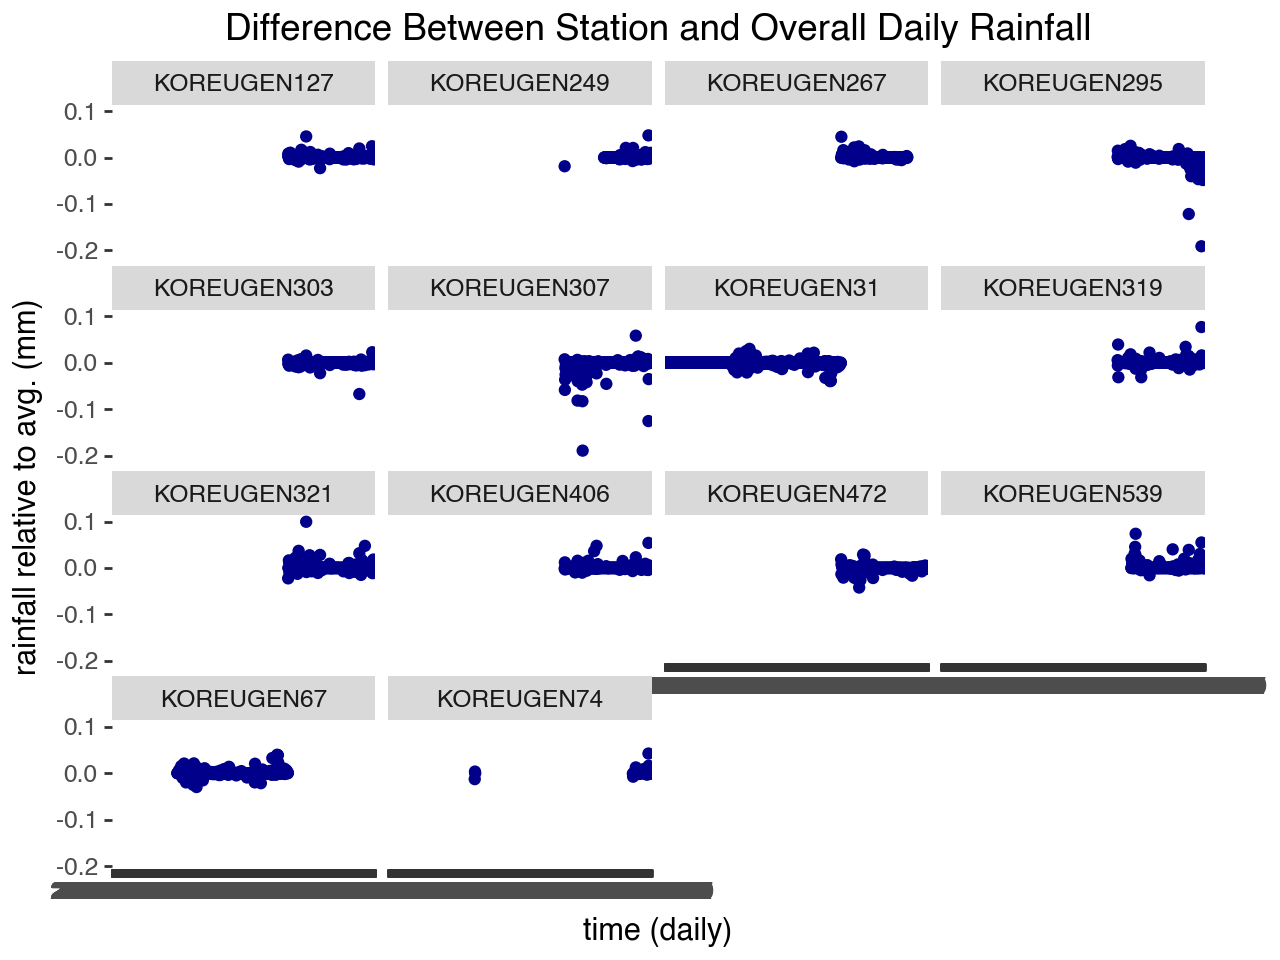

In [142]:
(
    p9.ggplot(data = compare_rain_d,
              mapping = p9.aes(x = "Date",
                               y = "rain_relative")) +
    p9.geom_point(color = "darkblue") +
    p9.facet_wrap("code") +
    p9.labs(title = "Difference Between Station and Overall Daily Rainfall",
            x = "time (daily)",
            y = "rainfall relative to avg. (mm)")

)

This graph shows, for each station, the difference between their daily rainfall and the average rainfall across all stations for that day, for every day of every year available in the data.

Similar to the previous graph, station based daily rainfall measurements are very representative of overall location averages of daily rainfall, with station based measurements differing by a fraction of a milimeter from the overall average. 

# Conclusion

Based on the questions we explored, I would conclude that the average measurements of precipitation data from all stations pretty accurately represent individual station precipitation data. However, this doesn't neccessarily mean that data from one specific station can predict what's happening at another station. But overall the precipitation data from these local weather stations do seem to follow the average in the region. 